# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [17]:
corpus = '''
The mountains looked beautiful as the morning sun slowly appeared above the horizon.
A group of travelers began their journey through the peaceful forest and followed a narrow path beside the river.
Birds were singing in the trees while cool wind moved gently through the green leaves.
After walking for several hours, the travelers reached a small village surrounded by hills and colorful flowers.
The local people welcomed them warmly and shared stories about the history and traditions of the region.
In the evening, everyone gathered near a campfire and watched the stars shining brightly in the clear night sky.
The journey gave the travelers an opportunity to explore nature, experience a different culture, and create unforgettable memories.
They returned home with beautiful photographs and stories that they would remember for many years.
'''
print(corpus)


The mountains looked beautiful as the morning sun slowly appeared above the horizon.
A group of travelers began their journey through the peaceful forest and followed a narrow path beside the river.
Birds were singing in the trees while cool wind moved gently through the green leaves.
After walking for several hours, the travelers reached a small village surrounded by hills and colorful flowers.
The local people welcomed them warmly and shared stories about the history and traditions of the region.
In the evening, everyone gathered near a campfire and watched the stars shining brightly in the clear night sky.
The journey gave the travelers an opportunity to explore nature, experience a different culture, and create unforgettable memories.
They returned home with beautiful photographs and stories that they would remember for many years.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 98
X shape: (125, 18)
y shape: (125,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [19]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [20]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [21]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

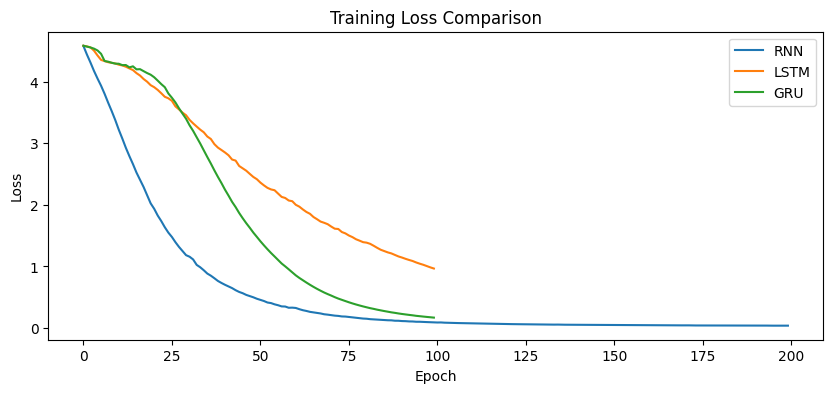

In [22]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [23]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [24]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning group of travelers began their journey through the peaceful forest
LSTM: deep learning walking walking the travelers travelers travelers reached a a small
GRU : deep learning were singing in the trees while cool wind moved gently


# 📚 Student Learning Tasks Completed
### ✅ Beginner Tasks
1.Replaced the default text corpus with a custom paragraph.

2.Increased the embedding dimension from 32 to 64.

3.Increased the training epochs from 100 to 200.

4.Increased the hidden layer size from 64 to 128 for the SimpleRNN, LSTM, and GRU models.

5.Modified the text generation function to generate 10 words instead of 5 from the given seed phrase.




# ✅ Conclusion
-Vanilla RNN effectively learns short-term sequential patterns but has difficulty remembering long-term dependencies because of the vanishing gradient problem.

-LSTM captures long-range contextual and grammatical relationships more effectively using its memory cell and gating mechanisms.

-GRU provides performance similar to LSTM with fewer gates, resulting in faster training and lower computational complexity.

-Increasing the embedding dimension, hidden units, training epochs, and generated output length improved the overall text generation capability.

-Overall, this experiment demonstrates the practical implementation of Vanilla RNN, LSTM, and GRU for text generation and helps students understand sequence modeling, next-word prediction, and recurrent neural networks from both theoretical and practical perspectives.